# 生成式 AI (ChatGPT vs Google Gemini) 的選擇和評論分析

In [62]:
# 載入套件
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize, MWETokenizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import re
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('vader_lexicon')
from wordcloud import WordCloud
import matplotlib.pyplot as plt

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\nini\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\nini\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\nini\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [63]:
# 設定圖的字體大小及字形
plt.rcParams['font.size'] = 14
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']

In [64]:
chatgpt_df = pd.read_csv('./raw_data/only_chatgpt.csv')
gemini_df = pd.read_csv('./raw_data/only_gemini.csv')

chatgpt_df['source'] = 'ChatGPT'
gemini_df['source'] = 'Gemini'
df_all = pd.concat([chatgpt_df, gemini_df], ignore_index=True)

# 合併並排除content為空值的資料
df_all = pd.concat([chatgpt_df, gemini_df], ignore_index=True).dropna(subset=['content'])

斷句

In [65]:
# 斷句
content_df = df_all.assign(sentence = df_all['content'].apply(lambda x: nltk.sent_tokenize(str(x))))\
                   .explode('sentence')\
                   .drop(['content'], axis=1)\
                   .reset_index(drop=True)

# content_df = content_df.reset_index(drop=True)
display(content_df.head())

,artDate,score,num_comments,url,source_subreddit,search_keyword,source,sentence
0,2025-05-19,1,1,https://www.reddit.com/r/ChatGPT/comments/1kqa...,ChatGPT,ChatGPT,ChatGPT,Why chatgpt has to be like this
1,2025-05-19,1,1,https://www.reddit.com/r/ChatGPT/comments/1kqa...,ChatGPT,ChatGPT,ChatGPT,"For a change, this is about deepseek gone wild..."
2,2025-05-19,1,1,https://www.reddit.com/r/ChatGPT/comments/1kqa...,ChatGPT,ChatGPT,ChatGPT,!!!!
3,2025-05-19,1,1,https://www.reddit.com/r/ChatGPT/comments/1kqa...,ChatGPT,ChatGPT,ChatGPT,I have attached the screenshot for more inform...
4,2025-05-19,1,1,https://www.reddit.com/r/ChatGPT/comments/1kqa...,ChatGPT,ChatGPT,ChatGPT,I asked it about MI death reckoning part 2 col...


移除無意義字、標點符號

In [66]:
def clean_and_protect_ai_dict(text):
    text = str(text).lower()

    # AI特有字典
    ai_terms = {
        "chat gpt": "chatgpt",
        "google gemini": "googlegemini",
        "gpt 4o": "gpt4o",
        "gpt 4": "gpt4",
        "gpt 3.5": "gpt35",
        "google ecosystem": "google_ecosystem",
        "open ai": "openai"

    }
    for old, new in ai_terms.items():
        text = text.replace(old, new)

    # 清除網址及標點符號
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'[\n]+', ' ', text)
    return text

content_df["clean_sentence"] = content_df["sentence"].apply(clean_and_protect_ai_dict)
content_df = content_df[content_df["clean_sentence"].str.len() > 1]

--句子層級的正負面情感評分--

In [67]:
sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = sia.polarity_scores(text)['compound']
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# sentiment是判斷該語句的正負向
content_df['sentiment'] = content_df['clean_sentence'].apply(get_sentiment)

設定斷詞

In [68]:
token_df = content_df.assign(token = content_df['clean_sentence'].apply(nltk.word_tokenize)).explode('token')
token_df.head(5)

,artDate,score,num_comments,url,source_subreddit,search_keyword,source,sentence,clean_sentence,sentiment,token
0,2025-05-19,1,1,https://www.reddit.com/r/ChatGPT/comments/1kqa...,ChatGPT,ChatGPT,ChatGPT,Why chatgpt has to be like this,why chatgpt has to be like this,Positive,why
0,2025-05-19,1,1,https://www.reddit.com/r/ChatGPT/comments/1kqa...,ChatGPT,ChatGPT,ChatGPT,Why chatgpt has to be like this,why chatgpt has to be like this,Positive,chatgpt
0,2025-05-19,1,1,https://www.reddit.com/r/ChatGPT/comments/1kqa...,ChatGPT,ChatGPT,ChatGPT,Why chatgpt has to be like this,why chatgpt has to be like this,Positive,has
0,2025-05-19,1,1,https://www.reddit.com/r/ChatGPT/comments/1kqa...,ChatGPT,ChatGPT,ChatGPT,Why chatgpt has to be like this,why chatgpt has to be like this,Positive,to
0,2025-05-19,1,1,https://www.reddit.com/r/ChatGPT/comments/1kqa...,ChatGPT,ChatGPT,ChatGPT,Why chatgpt has to be like this,why chatgpt has to be like this,Positive,be


字詞正規化 - 大小寫與 Stemming

In [69]:
# 轉為小寫
lowerWord_df = token_df.assign(word = token_df['token'].str.lower())

# Stemming
porter = PorterStemmer()
lowerWord_df['word'] = lowerWord_df['word'].astype(str)
stem_df = lowerWord_df.assign(stem_token = lowerWord_df['word'].apply(porter.stem)).reset_index(drop=True)

移除停用字

In [70]:
nltk.download('stopwords')
stops = set(stopwords.words('english'))
custom_stops = {
    'removed', 'deleted', 'would', 'one', 'get', 'like', 'use', 'im',
    'also', 'think', 'know', 'make', 'even', 'realli', 'peopl', 'time',
    'thing', 'say', 'go', 'see', 'want', 'look', 'dont', 'cant',
    'code', 'google', 'model', 'prompt', 'app' # 0321額外新增停用字
}
stops.update(custom_stops)

# 移除停用字
noStop_df = stem_df[~stem_df['word'].isin(stops)]
noStop_df = noStop_df[noStop_df['word'].str.len() > 1]

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nini\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [71]:
print("去除停用字前：", len(stem_df))
print("去除停用字後：", len(noStop_df))

去除停用字前： 247571
去除停用字後： 135695


計算字頻

In [72]:
cg_df = noStop_df[noStop_df['source'] == 'ChatGPT']
cg_freq_df = pd.DataFrame(cg_df['stem_token'].value_counts()).reset_index()
cg_freq_df.columns = ['word', 'freq']

print("ChatGPT:")
display(cg_freq_df.head(10))

gem_df = noStop_df[noStop_df['source'] == 'Gemini']
gem_freq_df = pd.DataFrame(gem_df['stem_token'].value_counts()).reset_index()
gem_freq_df.columns = ['word', 'freq']

print("Gemini:")
display(gem_freq_df.head(10))

ChatGPT:


,word,freq
0,chatgpt,1238
1,ai,718
2,gemini,549
3,use,466
4,ask,462
5,user,271
6,work,265
7,gener,260
8,imag,257
9,tri,250


Gemini:


,word,freq
0,gemini,899
1,ai,706
2,chatgpt,545
3,use,387
4,gener,271
5,ask,268
6,user,250
7,work,223
8,25,207
9,question,207


視覺化結果
利用詞頻製作文字雲，並顯示出詞頻最高的單字

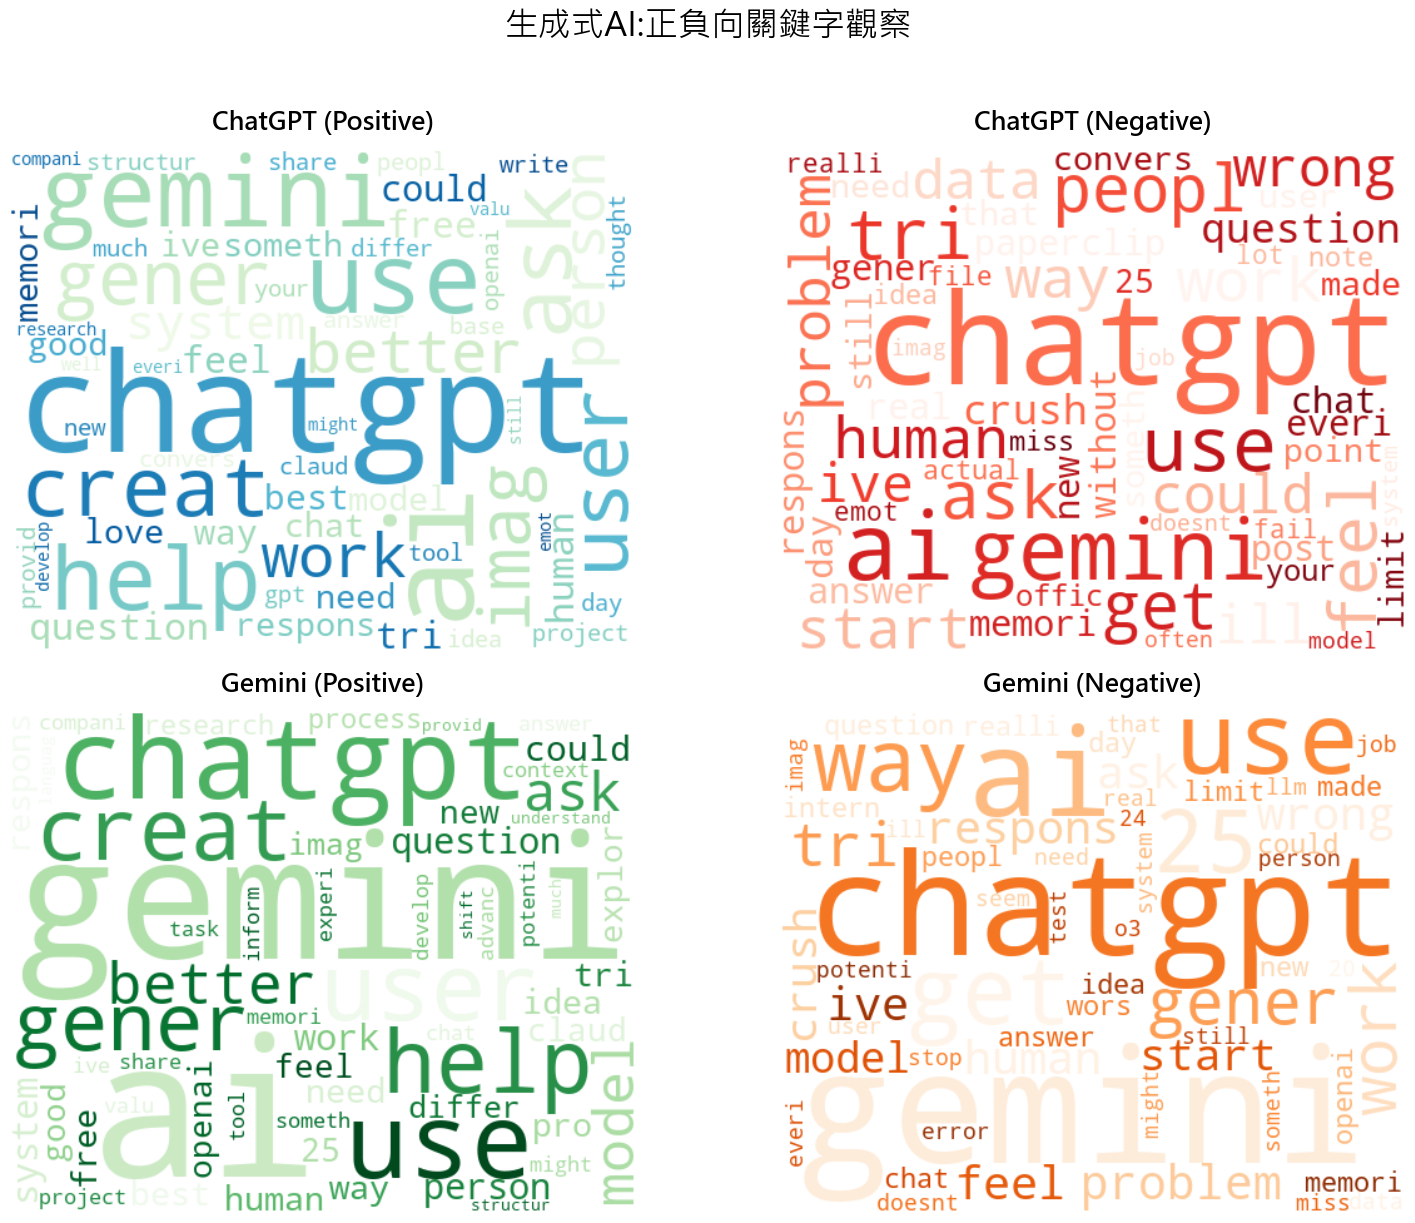

In [73]:
def plot_sentiment_wordcloud(df, source, sentiment, colormap, ax):
    # 特定AI平台與情緒資料
    filtered_df = df[(df['source'] == source) & (df['sentiment'] == sentiment)]

    if filtered_df.empty:
        ax.text(0.5, 0.5, 'No Data', ha='center', va='center', fontsize=20)
        ax.axis('off')
        return

    # 計算詞頻
    freq_dict = filtered_df['stem_token'].value_counts().to_dict()

    # 產生文字雲
    wc = WordCloud(
        background_color='white',
        width=500, height=400,
        colormap=colormap,
        max_words=60
    ).generate_from_frequencies(freq_dict)

    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{source} ({sentiment})', fontsize=18, fontweight='bold', pad=15)
    ax.axis('off')

# 視覺化呈現2x2 CANVAS
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('生成式AI:正負向關鍵字觀察', fontsize=24, y=1.02)

# ChatGPT的正向(藍綠色)、負向(紅色)
plot_sentiment_wordcloud(noStop_df, 'ChatGPT', 'Positive', 'GnBu', axes[0, 0])
plot_sentiment_wordcloud(noStop_df, 'ChatGPT', 'Negative', 'Reds', axes[0, 1])

# Gemini的正向(綠色)、負向(橘色)
plot_sentiment_wordcloud(noStop_df, 'Gemini', 'Positive', 'Greens', axes[1, 0])
plot_sentiment_wordcloud(noStop_df, 'Gemini', 'Negative', 'Oranges', axes[1, 1])

plt.tight_layout()
plt.show()

In [74]:
noStop_df.to_csv("./raw_data/clean_data.csv", encoding = 'utf-8', index = False)

### 3.語意探索

In [75]:
!pip install stanza ipywidgets wordcloud textblob


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [76]:
%pwd

'c:\\Users\\nini\\Desktop\\NSYSU\\studygroup1'

In [77]:
import stanza
from stanza.server import CoreNLPClient

import os
import pandas as pd

from nltk.parse import CoreNLPParser
from nltk.parse.corenlp import *
from nltk.corpus import stopwords

from wordcloud import WordCloud

import matplotlib.pyplot as plt

In [78]:
stanza.install_corenlp("./stanza_corenlp")

2026-03-30 18:21:20 INFO: Installing CoreNLP package into ./stanza_corenlp


2026-03-30 18:22:09 INFO: Downloaded file to ./stanza_corenlp\corenlp.zip
2026-03-30 18:22:12 WARNING: For customized installation location, please set the `CORENLP_HOME` environment variable to the location of the installation. In Unix, this is done with `export CORENLP_HOME=./stanza_corenlp`.


In [79]:
os.environ['CORENLP_HOME'] = "./stanza_corenlp"

In [80]:
# 讀取資料
df = pd.read_csv('./raw_data/clean_data.csv')
df_sentences = df.drop_duplicates(subset=['url', 'sentence']).copy()

In [81]:
import pandas as pd
import time
# 假設你已經匯入了 CoreNLPClient

def get_nlp_result(df, text_col='sentence', id_col='url', source_col='source'):
    print("Starting a server with the Python \"with\" statement...")

    stsrt = time.time()

    with CoreNLPClient(
        annotators=['tokenize','ssplit','pos','lemma','ner','entitymentions'],
        timeout=60000, memory='4G', endpoint='http://localhost:7777', be_quiet=True
    ) as client:

        token_list = []
        mention_list = []

        for index, row in df.iterrows():
            try:
                document = client.annotate(str(row[text_col]))

                for i, sent in enumerate(document.sentence):
                    s = ""
                    for t in sent.token:
                        s = s + t.word + " "
                        temp_token = [row[id_col], row[source_col], t.word, t.lemma, t.pos, t.ner]
                        token_list.append(temp_token)

                    for mention in sent.mentions:
                        try:
                            temp_mention = [row[id_col], row[source_col], mention.entityMentionText, mention.ner]
                            mention_list.append(temp_mention)
                        except:
                            continue

            except Exception as e:
                continue


    token_table = pd.DataFrame(data=token_list, columns=['url','source','word','lemma','pos','ner'])
    mention_table = pd.DataFrame(data=mention_list, columns=['url','source','mention','ner'])

    end = time.time()

    print("time costing: {:.2f} 秒".format(end-stsrt))
    print("\nThe server should be stopped upon exit from the \"with\" statement.")

    return token_table, mention_table

In [82]:
# 找出 NER、POS
tokens, mention = get_nlp_result(df_sentences, text_col='sentence')

2026-03-30 18:22:14 INFO: Writing properties to tmp file: corenlp_server-fadeb301604a4f89.props
2026-03-30 18:22:14 INFO: Starting server with command: java -Xmx4G -cp ./stanza_corenlp\* edu.stanford.nlp.pipeline.StanfordCoreNLPServer -port 7777 -timeout 60000 -threads 5 -maxCharLength 100000 -quiet True -serverProperties corenlp_server-fadeb301604a4f89.props -annotators tokenize,ssplit,pos,lemma,ner,entitymentions -preload -outputFormat serialized


Starting a server with the Python "with" statement...
time costing: 899.35 秒

The server should be stopped upon exit from the "with" statement.


In [83]:
tokens.head()

,url,source,word,lemma,pos,ner
0,https://www.reddit.com/r/ChatGPT/comments/1kqa...,ChatGPT,Why,why,WRB,O
1,https://www.reddit.com/r/ChatGPT/comments/1kqa...,ChatGPT,chatgpt,chatgpt,NN,O
2,https://www.reddit.com/r/ChatGPT/comments/1kqa...,ChatGPT,has,have,VBZ,O
3,https://www.reddit.com/r/ChatGPT/comments/1kqa...,ChatGPT,to,to,TO,O
4,https://www.reddit.com/r/ChatGPT/comments/1kqa...,ChatGPT,be,be,VB,O


In [84]:
mention.head()

,url,source,mention,ner
0,https://www.reddit.com/r/ChatGPT/comments/1kqa...,ChatGPT,first,ORDINAL
1,https://www.reddit.com/r/ChatGPT/comments/1kqa...,ChatGPT,MI,STATE_OR_PROVINCE
2,https://www.reddit.com/r/ChatGPT/comments/1kqa...,ChatGPT,2,NUMBER
3,https://www.reddit.com/r/ChatGPT/comments/1kqa...,ChatGPT,2024,DATE
4,https://www.reddit.com/r/ChatGPT/comments/1kqa...,ChatGPT,Deepseek,PERSON


In [85]:
# 儲存結果
tokens.to_csv('tokens_tp.csv', encoding = 'utf-8', index = False)
mention.to_csv('mention_tp.csv', encoding = 'utf-8', index = False)

##### 探索分析 - NER

In [86]:
# 讀取已經執行完畢的結果
tokens = pd.read_csv('tokens_tp.csv')
mention = pd.read_csv('mention_tp.csv')

NER 種類分析

In [87]:
mention['word_lower'] = mention['mention'].str.lower()
tokens['word_lower'] = tokens['word'].str.lower()

In [88]:
# 查看辨識出哪幾種 NER
tokens['ner'].unique()

array(['O', 'ORDINAL', 'STATE_OR_PROVINCE', 'NUMBER', 'DATE', 'PERSON',
       'DURATION', 'TITLE', 'ORGANIZATION', 'COUNTRY', 'URL', 'TIME',
       'CITY', 'LOCATION', 'NATIONALITY', 'MISC', 'SET', 'IDEOLOGY',
       'HANDLE', 'RELIGION', 'PERCENT', 'MONEY', 'CAUSE_OF_DEATH',
       'CRIMINAL_CHARGE'], dtype=object)

In [89]:
len(tokens.loc[tokens['ner'] != '0']['word'].unique())

17036

In [90]:
mention['ner'].unique()

array(['ORDINAL', 'STATE_OR_PROVINCE', 'NUMBER', 'DATE', 'PERSON',
       'DURATION', 'TITLE', 'ORGANIZATION', 'COUNTRY', 'URL', 'TIME',
       'CITY', 'LOCATION', 'NATIONALITY', 'MISC', 'SET', 'IDEOLOGY',
       'HANDLE', 'RELIGION', 'PERCENT', 'MONEY', 'CAUSE_OF_DEATH',
       'CRIMINAL_CHARGE'], dtype=object)

NER 類別統計

In [91]:
# 進行類別統計
ner_count = mention.groupby(['ner'])['ner'].count().reset_index(name='count').sort_values(['count'], ascending=False).head(10)
ner_count

,ner,count
12,NUMBER,2752
16,PERSON,1244
4,DATE,1192
21,TITLE,835
14,ORGANIZATION,809
5,DURATION,467
9,MISC,349
22,URL,279
13,ORDINAL,176
8,LOCATION,137


C:\Users\nini\AppData\Local\Temp\ipykernel_16380\3985747297.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


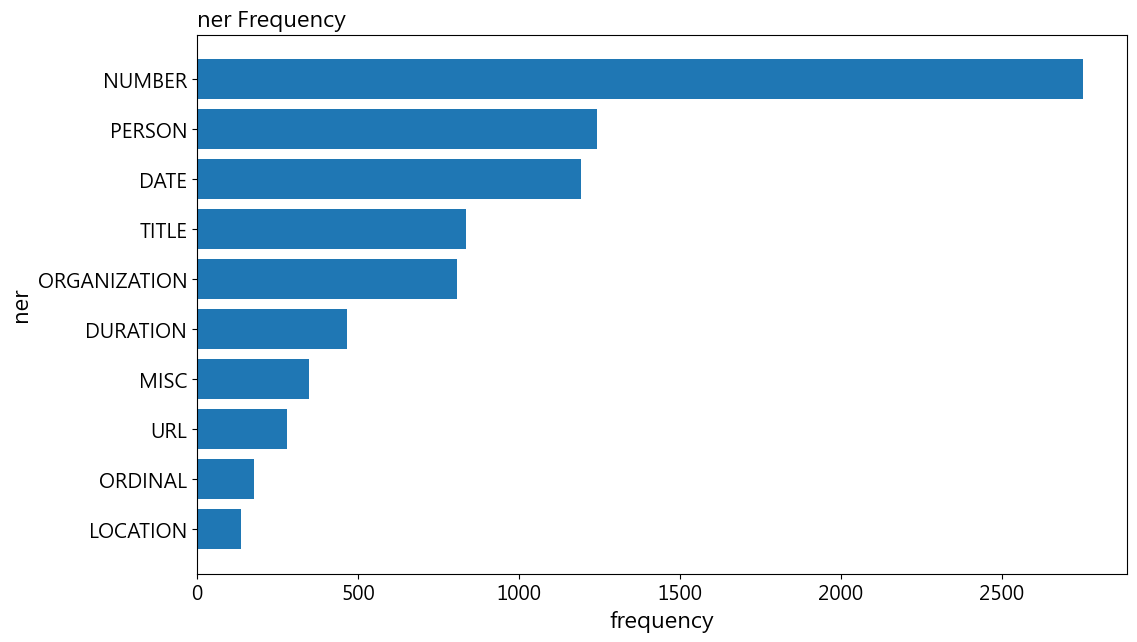

In [92]:
ner = ner_count['ner']
count= ner_count['count']

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(ner, count)
ax.invert_yaxis()
ax.set_title('ner Frequency', loc = 'left', size = 16)
ax.set_ylabel('ner', size = 16)
ax.set_xlabel('frequency', size = 16)
fig.show()

分別統計 ChatGPT 和 Gemini 的類別

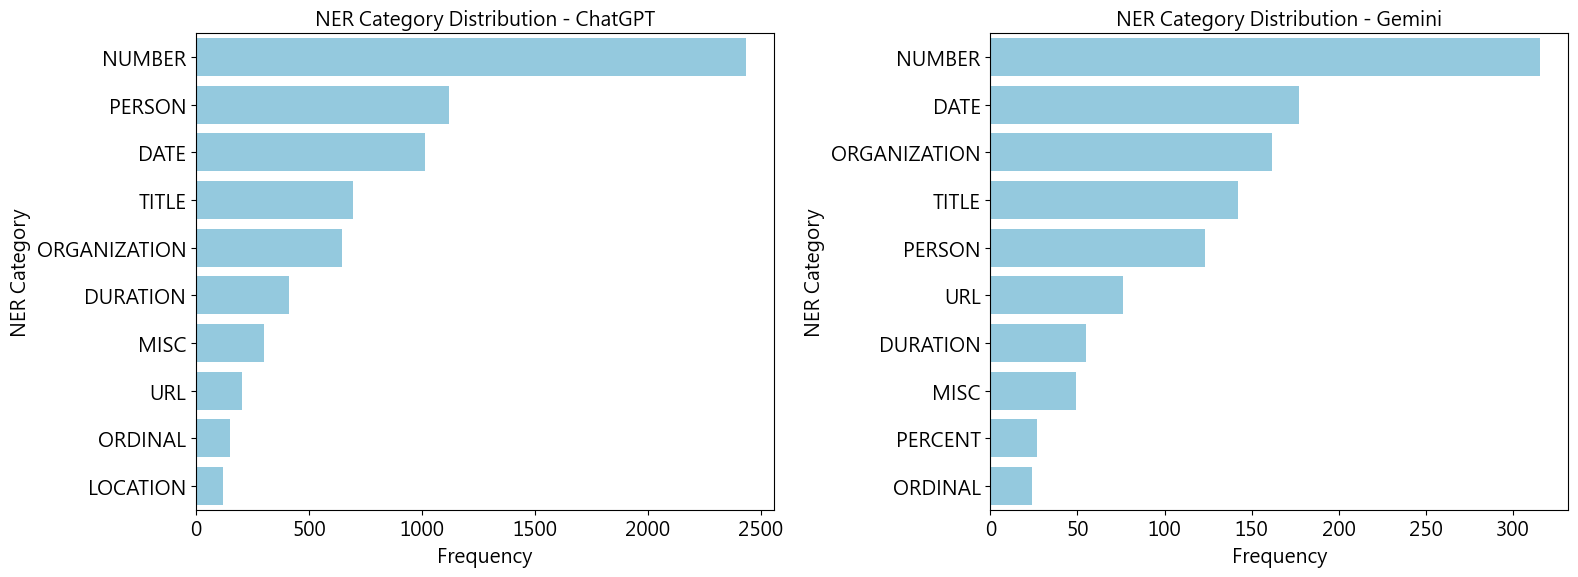

In [93]:
import seaborn as sns

ner_comparison = mention.groupby(['source', 'ner']).size().reset_index(name='count')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
camps = [('ChatGPT', ax1), ('Gemini', ax2)]
for camp_name, ax in camps:
    camp_data = ner_comparison[ner_comparison['source'] == camp_name].sort_values('count', ascending=False).head(10)
    sns.barplot(data=camp_data, x='count', y='ner', ax=ax, color='skyblue')
    
    ax.set_title(f'NER Category Distribution - {camp_name}', size=14)
    ax.set_xlabel('Frequency')
    ax.set_ylabel('NER Category')
plt.tight_layout()
plt.show()

涉及到的組織(ORG)

In [94]:
# 篩選 ner 為 organization 的資料
org = mention[mention['ner'] == 'ORGANIZATION']

# 計算每個組織提到的次數，選出前8個
org_count = org[['word_lower']].groupby(['word_lower'])['word_lower'].count().reset_index(name='count')
org_count = org_count.sort_values(['count'], ascending=False).head(8)
org_count

,word_lower,count
80,google,311
96,gpt,105
139,microsoft,22
208,youtube,21
99,grok,14
133,mcp,14
5,agi,11
163,porl,8


Text(0.5, 0, 'Word Frequency')

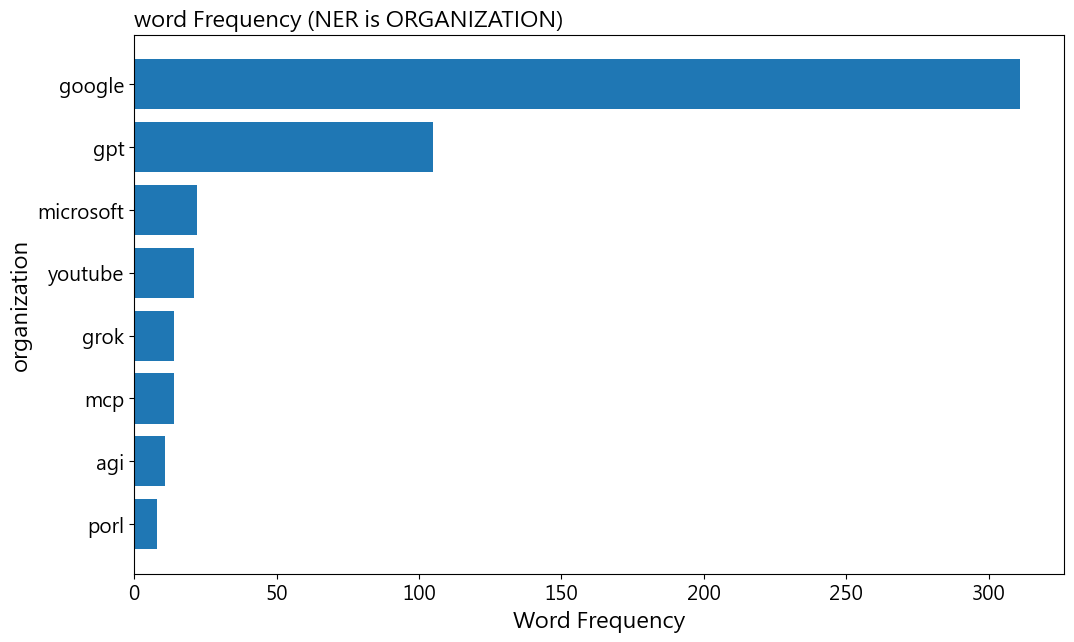

In [95]:
word = org_count['word_lower']
count = org_count['count']

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(word, count)
ax.invert_yaxis()
ax.set_title('word Frequency (NER is ORGANIZATION)', loc = 'left', size = 16)
ax.set_ylabel('organization', size = 16)
ax.set_xlabel('Word Frequency', size = 16)
# fig.show()

形容詞分析

In [96]:
adj = tokens[tokens['pos'].str.startswith('JJ')]
for camp in ['ChatGPT', 'Gemini']:
    print(f"\n{camp} 形容詞分析")
    stop_adj = ['other', 'more', 'such', 'own', 'same', 'sure', 'last', 'able', 'many', 'prompt', 'human']
    adj_camp = adj[(adj['source'] == camp) & (~adj['word_lower'].isin(stop_adj))]
    df_adj = adj_camp['word'].value_counts().head(10).reset_index()
    df_adj.columns = ['Word', 'Count']
    display(df_adj)


ChatGPT 形容詞分析


,Word,Count
0,new,147
1,real,126
2,different,122
3,better,118
4,free,106
5,personal,100
6,good,98
7,best,79
8,specific,67
9,high,67



Gemini 形容詞分析


,Word,Count
0,internal,48
1,new,37
2,different,36
3,specific,33
4,better,29
5,creative,28
6,large,24
7,good,22
8,complex,21
9,real,21


動詞分析

In [97]:
verbs = tokens[tokens['pos'].str.startswith('VB')]
for camp in ['ChatGPT', 'Gemini']:
    print(f"\n{camp} 動詞分析")
    stop_verbs = ['be', 'have', 'do', 'get', 'make', 'go', 'can', 'will', 'say']
    v_camp = verbs[(verbs['source'] == camp) & (~verbs['lemma'].str.lower().isin(stop_verbs))]
    df_v = v_camp['lemma'].str.lower().value_counts().head(10).reset_index()
    df_v.columns = ['Verb_Lemma', 'Count']
    display(df_v)


ChatGPT 動詞分析


,Verb_Lemma,Count
0,use,677
1,ask,460
2,know,268
3,try,241
4,feel,239
5,think,233
6,see,231
7,give,224
8,want,220
9,create,216



Gemini 動詞分析


,Verb_Lemma,Count
0,use,131
1,generate,75
2,ask,75
3,create,62
4,try,59
5,need,50
6,give,42
7,see,41
8,think,40
9,know,38


競爭對手、其他產品詞頻統計

In [98]:
comp_list = [
    'google', 'openai', 'microsoft', 'claude', 'anthropic', 
    'deepseek', 'perplexity', 'llama', 'meta', 'mistral'
]

comp_df = tokens[tokens['word_lower'].isin(comp_list)].copy()

comp_table = comp_df.pivot_table(
    index='word_lower', 
    columns='source', 
    values='word', 
    aggfunc='count'
).fillna(0).astype(int)

comp_table.index.name = 'Competitor'
comp_table = comp_table.sort_values(by=['ChatGPT', 'Gemini'], ascending=False)
print("競爭對手提及次數")
display(comp_table)

競爭對手提及次數


source,ChatGPT,Gemini
Competitor,,
google,258,139
claude,148,11
openai,142,28
deepseek,58,13
perplexity,40,11
meta,32,8
anthropic,20,4
microsoft,19,4
llama,13,5


功能特徵詞頻統計

In [99]:
feature_list = ['prompt', 'api', 'code', 'ui', 'vision', 'logic', 'plugin', 'mobile',
                'debug', 'speed', 'voice', 'image', 'multimodal', 'search', 'integration'
]

feat_df = tokens[tokens['word_lower'].isin(feature_list)].copy()

feat_table = feat_df.pivot_table(
    index='word_lower', 
    columns='source', 
    values='word', 
    aggfunc='count'
).fillna(0).astype(int)

feat_table.index.name = 'Feature'
feat_table = feat_table.sort_values(by=['ChatGPT', 'Gemini'], ascending=False)
print("功能特徵提及次數")
display(feat_table)

功能特徵提及次數


source,ChatGPT,Gemini
Feature,,
image,195,36
prompt,180,31
code,104,31
voice,90,14
search,71,21
api,59,11
logic,55,1
speed,22,3
ui,19,3
